# Análisis Exploratorio de Datos (EDA) y Perfilamiento Táctico

## 1. Carga del Ecosistema de Datos

En esta etapa, importamos nuestra matriz de datos enriquecida. Este dataset ya pasó por un riguroso proceso de *Feature Engineering*, donde extrajimos 16 variables tácticas estandarizadas por 90 minutos (P90) y ajustadas por posesión (PAdj), además de incluir variables categóricas clave como la liga y la posición del jugador.

In [3]:
import pandas as pd
from IPython.display import display

print("="*85)
print(" 📊 INICIO DE ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("="*85)

# 1. Definir la ruta del NUEVO archivo enriquecido
ruta_archivo = '/content/drive/MyDrive/dataset_master_enriquecido_1516.csv'

# 2. Cargar los datos a memoria
df_modelo_final = pd.read_csv(ruta_archivo)

print(f"✅ Base de datos cargada: {df_modelo_final.shape[0]} jugadores analizados con {df_modelo_final.shape[1]} atributos.")
print("✅ ¡Las métricas tácticas y los valores de mercado están listos para analizarse!")
print("-" * 85)

# Vista previa de las primeras filas para asegurar que la estructura esté intacta
display(df_modelo_final.head())

 📊 INICIO DE ANÁLISIS EXPLORATORIO DE DATOS (EDA)
✅ Base de datos cargada: 1699 jugadores analizados con 27 atributos.
✅ ¡Las métricas tácticas y los valores de mercado están listos para analizarse!
-------------------------------------------------------------------------------------


,player,team,competition_name,position_group,position_detail,minutos_jugados,xG P90,xG por Tiro,Asistencias a Tiro P90,% Centralidad Equipo,...,Recup. Último Tercio P90,Conducciones Progresivas P90,Influencia Global P90,Faltas Recibidas P90,Pérdidas de Balón P90,value_eur,wage_eur,age,weight_kg,height_cm
0,Aaron Cresswell,West Ham United,Premier League,Defensa,Left Back,3398,0.021197,0.029640,1.085933,11.456168,...,0.979988,2.834020,147.872278,0.927016,1.430253,3000000.0,35000.0,25.0,66.0,170.0
1,Aaron Lennon,Everton,Premier League,Delantero,Right Wing,2130,0.082510,0.108485,0.887324,2.772703,...,1.225352,2.915493,98.704225,1.098592,1.732394,625000.0,8000.0,29.0,74.0,180.0
2,Aaron Ramsey,Arsenal,Premier League,Mediocampista,Left Defensive Midfield,2826,0.234788,0.110035,1.082803,9.927251,...,2.229299,5.477707,256.401274,1.815287,3.949045,26000000.0,130000.0,24.0,70.0,177.0
3,Abdelaziz Barrada,Marseille,Ligue 1,Mediocampista,Left Center Midfield,1902,0.038600,0.407878,0.473186,4.092397,...,0.283912,0.899054,34.826498,0.283912,0.567823,4300000.0,60000.0,26.0,73.0,179.0
4,Abdelaziz Barrada,Olympique de Marseille,Ligue 1,Mediocampista,Center Attacking Midfield,1902,0.133185,0.117276,2.176656,5.601139,...,1.135647,3.264984,131.072555,1.041009,1.561514,4300000.0,60000.0,26.0,73.0,179.0


## 2. Auditoría Numérica y Distribución Global (Violin Plots)

Antes de segmentar la información por ligas o posiciones, es imperativo entender la topología total de nuestras variables. Para lograr un análisis profundo en "dos dimensiones", combinamos:
1.  **Estadística Descriptiva:** Medidas de tendencia central (Media, Mediana) y dispersión (Desviación Estándar, Cuartiles) para obtener los límites matemáticos duros.
2.  **Gráficos de Violín (Violin Plots):** Una técnica visual avanzada que fusiona un diagrama de caja (*Boxplot*) con una curva de densidad de probabilidad (*KDE*), permitiéndonos observar exactamente dónde se aglomera el volumen de jugadores.

### 🔍 Hallazgos Principales y Naturaleza de los Datos

Al cruzar los resultados de la tabla descriptiva con la forma de los gráficos de densidad, extraemos las siguientes conclusiones sobre el ecosistema del fútbol europeo:

*   **Inflación de Ceros y la "Rareza del Gol" (Asimetría Positiva):**
    La inmensa mayoría de los gráficos muestran su pico máximo de densidad (la parte más ancha del violín) exactamente en el `0` o ligeramente por encima, donde empiezan a caer con pequeñas fluctuaciones en algunos casos, seguido de una larga y fina cola hacia la derecha. Este fenómeno se acentúa drásticamente en las métricas relacionadas directamente con el gol (`xG P90`, `xG por Tiro`). Esto tiene total sentido táctico: son las acciones más codiciadas, escasas y determinantes del deporte. La élite que genera estas jugadas compone un porcentaje minúsculo de la población total.
    
*   **El Comportamiento Único de la Influencia Global:**
    A diferencia del resto de las variables que concentran su pico de densidad cerca del `0`, la métrica `Influencia Global P90` se comporta de manera distinta al registrar su pico más alto de densidad cercano al valor de **130**. Es una de las únicas que no sigue el patrón general, lo cual es completamente lógico ya que representa el cómputo total de todas las acciones e intervenciones que ejecuta el jugador en el partido, elevando de forma natural su escala numérica promedio.

*   **La Anatomía Multimodal de los Porcentajes:**
    El `% de Pases de Seguridad` es la gran excepción visual. A diferencia del resto, no tiene un solo pico en cero, sino que muestra una distribución con múltiples densidades. Su masa principal se centra alrededor del **40%** (que es el estándar general del jugador promedio), pero presenta picos inusuales cerca del **0%**. Matemáticamente, esto ocurre al dividir por el total de pases: jugadores (o porteros) con muy poca participación en el juego pueden registrar un 0% de seguridad con tan solo realizar o fallar un único pase.

*   **⚠️ Alerta de Calidad de Datos (Data Quality):**
    La tabla descriptiva nos revela que la métrica `Duelos Aéreos Ganados P90` arrojó un valor de `0.000` en su promedio, máximos y todos sus cuartiles. Esto es un fuerte indicativo estructural de la API para la temporada 15/16: es altamente probable que el proveedor de datos (StatsBomb) no haya catalogado los duelos aéreos con la nomenclatura estándar durante esa campaña específica. Esta variable deberá ser observada con cautela o descartada en el posterior modelado (PCA) al no aportar varianza matemática.

 📊 ESTADÍSTICAS DESCRIPTIVAS: UNIVERSO GLOBAL DE JUGADORES


,Nulos,Conteo,Promedio,Desv. Estándar,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Máximo
xG P90,0,1699.0,0.084,0.106,0.0,0.018,0.048,0.110,0.894
xG por Tiro,0,1699.0,0.081,0.058,0.0,0.043,0.074,0.110,0.765
Asistencias a Tiro P90,0,1699.0,0.550,0.490,0.0,0.180,0.441,0.776,3.566
% Centralidad Equipo,0,1699.0,4.826,2.889,0.0,2.520,4.457,6.836,15.617
Pases Progresivos P90,0,1699.0,12.366,7.890,0.0,5.067,12.234,18.189,35.201
Pases Último Tercio P90,0,1699.0,10.750,6.669,0.0,5.411,9.629,15.162,41.840
% Pases Seguridad,0,1699.0,36.422,14.590,0.0,28.398,37.320,46.817,77.778
% Pases Bajo Presión,0,1699.0,4.359,1.204,0.0,3.655,4.351,4.999,11.141
Intercepciones PAdj P90,0,1699.0,0.869,0.687,0.0,0.292,0.766,1.329,3.494
Tackles Ganados PAdj P90,0,1699.0,0.800,0.575,0.0,0.365,0.710,1.145,3.225



 🎻 DISTRIBUCIÓN GLOBAL DE LAS MÉTRICAS (VIOLIN PLOTS)


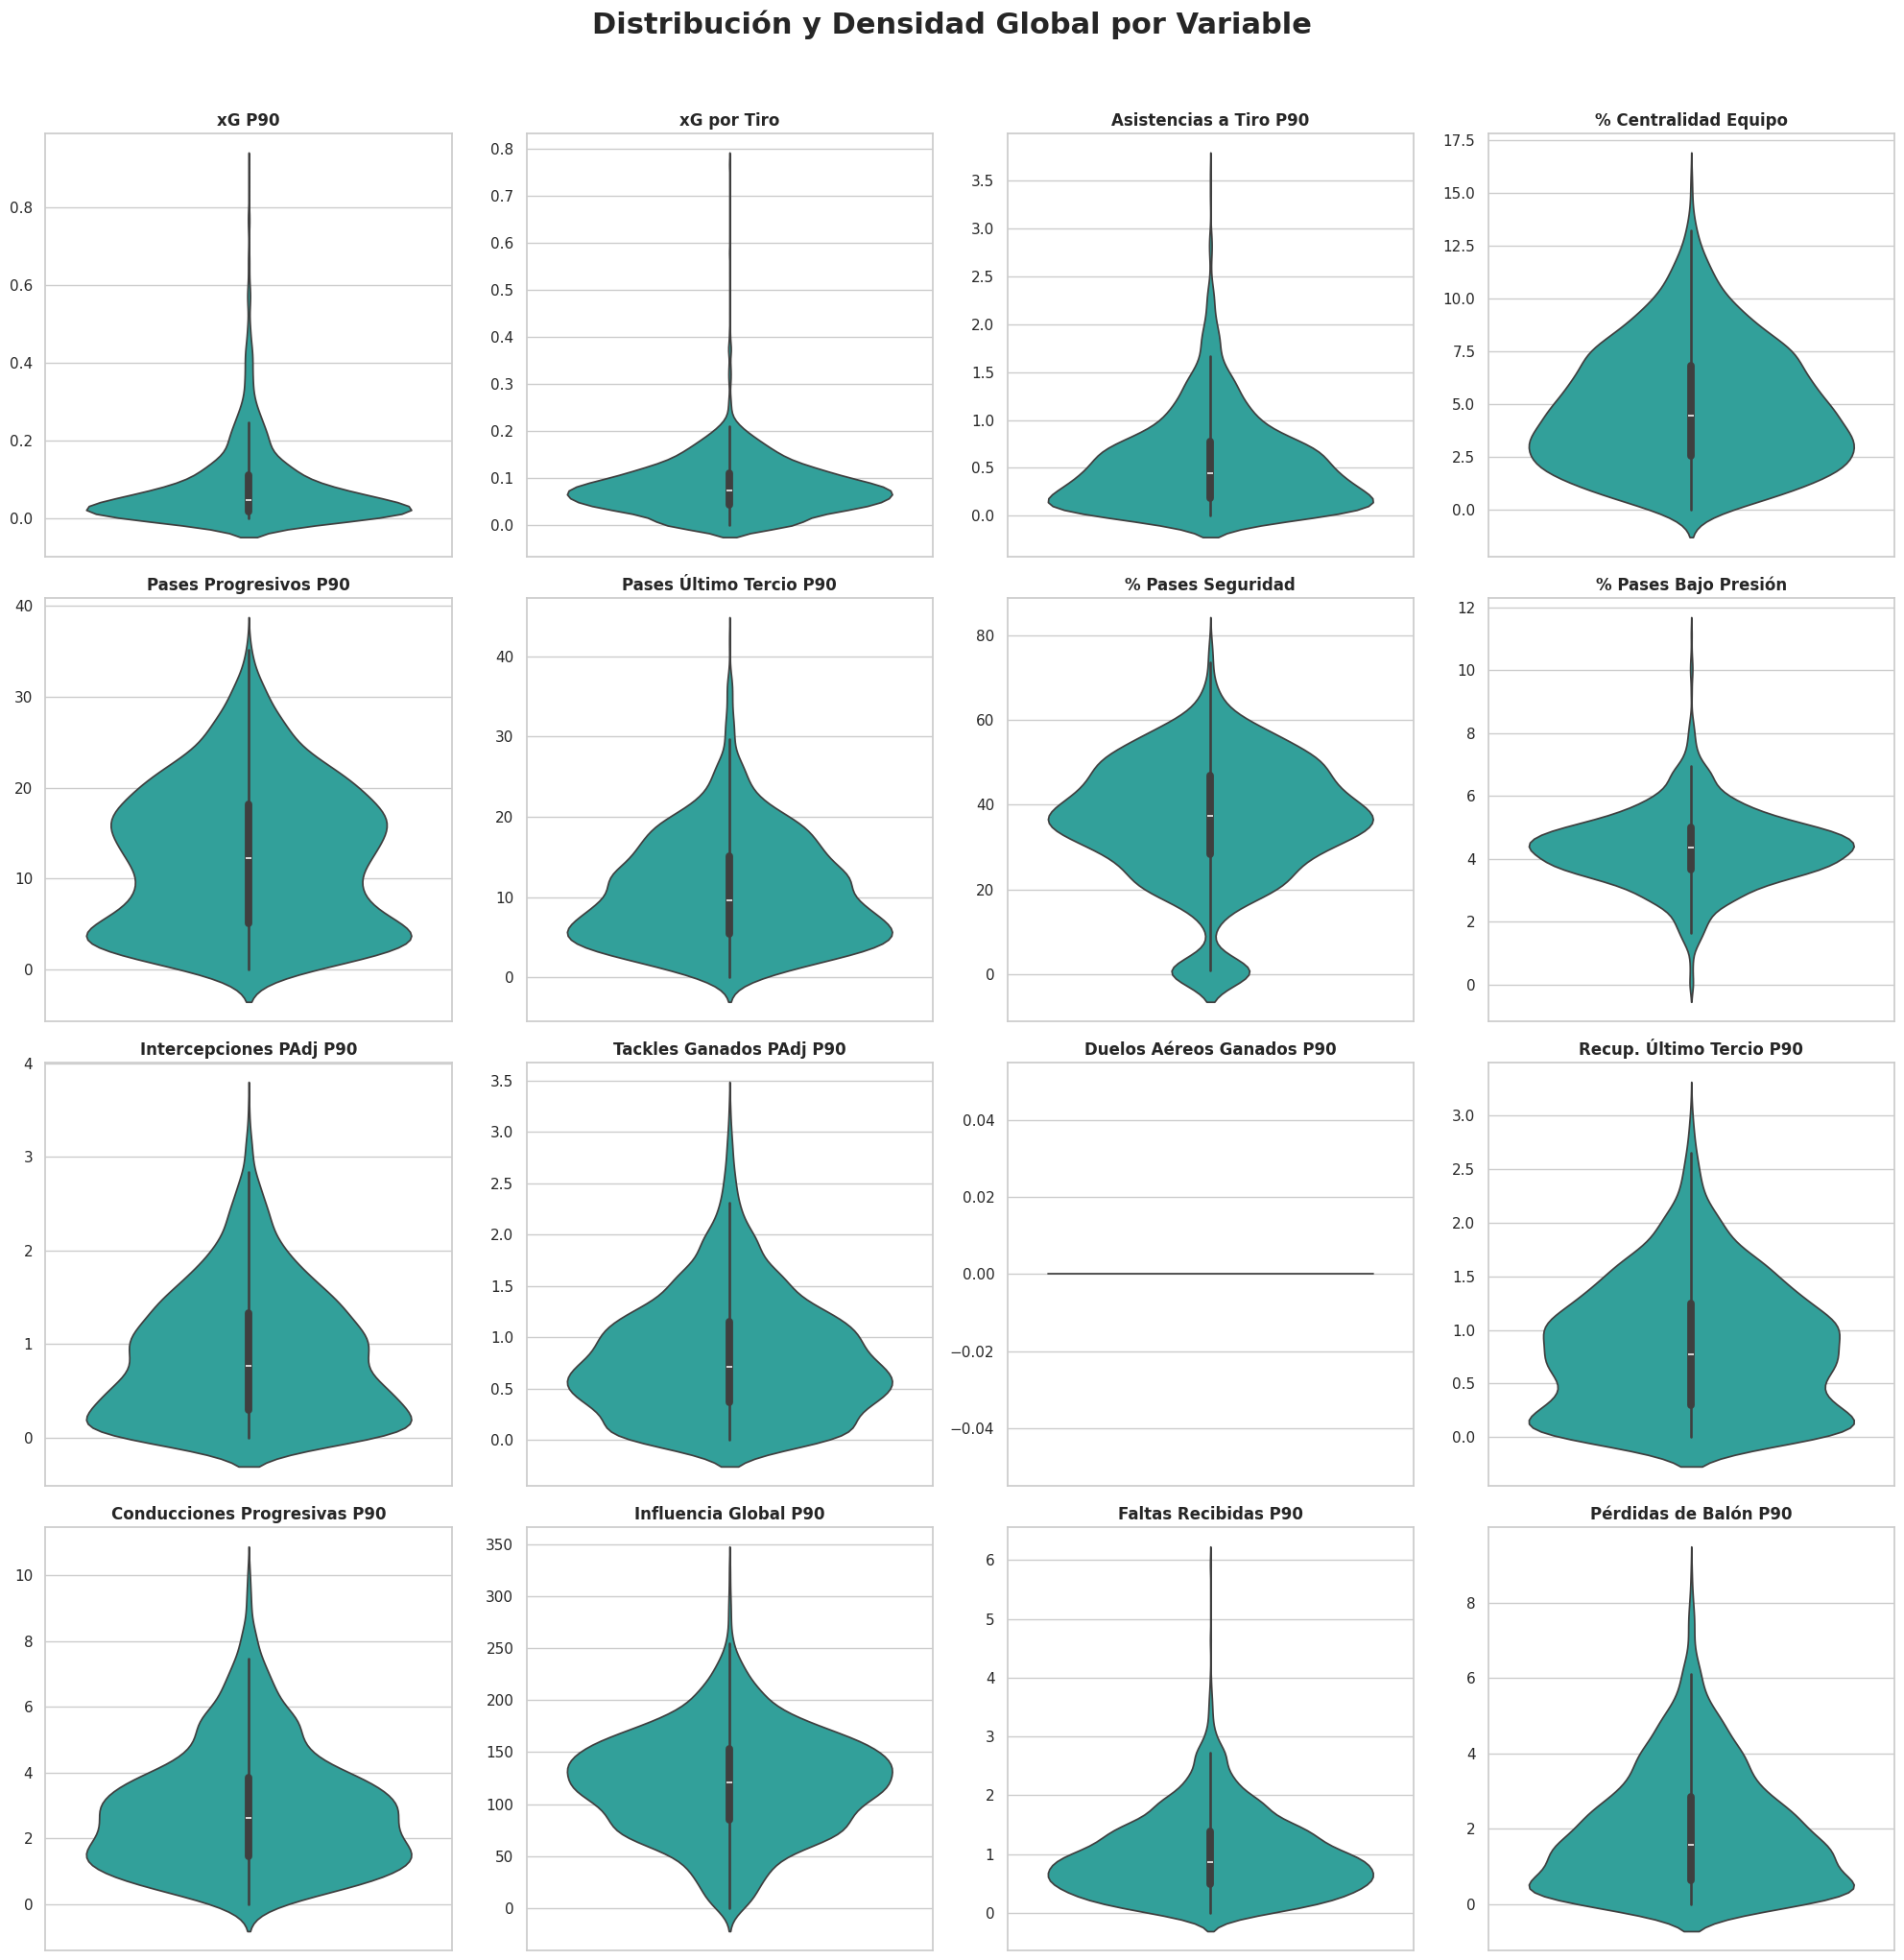

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("="*100)
print(" 📊 ESTADÍSTICAS DESCRIPTIVAS: UNIVERSO GLOBAL DE JUGADORES")
print("="*100)

# Definir las 16 columnas métricas del modelo
columnas_modelo = [
    'xG P90', 'xG por Tiro', 'Asistencias a Tiro P90',
    '% Centralidad Equipo', 'Pases Progresivos P90', 'Pases Último Tercio P90',
    '% Pases Seguridad', '% Pases Bajo Presión',
    'Intercepciones PAdj P90', 'Tackles Ganados PAdj P90',
    'Duelos Aéreos Ganados P90', 'Recup. Último Tercio P90',
    'Conducciones Progresivas P90', 'Influencia Global P90',
    'Faltas Recibidas P90', 'Pérdidas de Balón P90'
]

# Generar el resumen estadístico con la función describe() transpuesta para mejor lectura
resumen_total = df_modelo_final[columnas_modelo].describe().T

# Agregar columna de valores nulos como control de calidad
resumen_total['Valores Nulos'] = df_modelo_final[columnas_modelo].isnull().sum()

# Reordenar las columnas de forma analítica
resumen_total = resumen_total[['Valores Nulos', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# Renombrar en español para el reporte
resumen_total.columns = [
    'Nulos', 'Conteo', 'Promedio', 'Desv. Estándar',
    'Mínimo', 'Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)', 'Máximo'
]

# 1. Mostrar la tabla de estadísticas
display(resumen_total.round(3))

# ==============================================================================
# 2. VISUALIZACIÓN GLOBAL: VIOLIN PLOTS DE DENSIDAD
# ==============================================================================
print("\n" + "="*100)
print(" 🎻 DISTRIBUCIÓN GLOBAL DE LAS MÉTRICAS (VIOLIN PLOTS)")
print("="*100)

# Configuración visual
sns.set_theme(style="whitegrid")

# Crear el lienzo 4x4
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
fig.suptitle('Distribución y Densidad Global por Variable', fontsize=22, y=1.02, fontweight='bold')
axes = axes.flatten()

# Generar un Violin Plot vertical para cada variable en el universo global
for i, col in enumerate(columnas_modelo):
    sns.violinplot(y=df_modelo_final[col], ax=axes[i], color='lightseagreen', inner='box')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Comparación Táctica por Liga y Análisis de Valores Atípicos (Outliers)

Tras comprender el comportamiento global, el siguiente paso metodológico es segmentar la información por competición (Premier League, La Liga, Serie A, Ligue 1) para evaluar si existen diferencias estructurales que puedan sesgar nuestro futuro modelo. Para ello, combinamos tres técnicas:
1.  **Promedios y Volatilidad:** Tablas cruzadas para identificar tendencias generales.
2.  **Gráficos de Violín por Liga:** Para comparar visualmente la forma de las densidades y la dispersión.
3.  **Extracción de Extremos (Top 3):** Identificación directa de los jugadores que empujan las colas de las distribuciones.

### 🟢 Luz Verde Estadística: Homogeneidad Estructural
El hallazgo más importante de los *Violin Plots* segmentados es que **no existen diferencias drásticas en la densidad entre las ligas**. La "pancita" (el grueso de la población) y el comportamiento de las métricas siguen la misma distribución matemática en Inglaterra, España, Italia y Francia.

Esta es una excelente noticia para el modelado: significa que el fútbol de élite europeo funciona como un ecosistema táctico homogéneo. Al no existir un sesgo masivo por liga, tenemos la justificación estadística perfecta para aplicar una **Estandarización Global** en nuestro Análisis de Componentes Principales (PCA), sin necesidad de aislar los datos por país.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print(" 🌍 COMPARACIÓN TÁCTICA: PROMEDIOS MÉTRICOS POR LIGA")
print("="*80)

# Agrupar los datos por el nombre de la liga y calcular la media de las variables
resumen_liga_media = df_modelo_final.groupby('competition_name')[columnas_modelo].mean().T

# Ordenar las ligas alfabéticamente en las columnas para estandarizar la vista
resumen_liga_media = resumen_liga_media.sort_index(axis=1)

# Desplegar el DataFrame comparativo
display(resumen_liga_media.round(3))

print("\n" + "="*80)
print(" 🔍 COMPARACIÓN DE VOLATILIDAD: DESVIACIÓN ESTÁNDAR POR LIGA")
print("="*80)

# (Opcional) Ver la dispersión: ¿En qué liga hay más desigualdad entre los jugadores top y el resto?
resumen_liga_std = df_modelo_final.groupby('competition_name')[columnas_modelo].std().T
resumen_liga_std = resumen_liga_std.sort_index(axis=1)

display(resumen_liga_std.round(3))


 🌍 COMPARACIÓN TÁCTICA: PROMEDIOS MÉTRICOS POR LIGA


competition_name,La Liga,Ligue 1,Premier League,Serie A
xG P90,0.091,0.074,0.089,0.082
xG por Tiro,0.082,0.082,0.081,0.078
Asistencias a Tiro P90,0.546,0.477,0.596,0.591
% Centralidad Equipo,4.963,4.701,4.975,4.695
Pases Progresivos P90,12.990,11.897,12.568,12.101
Pases Último Tercio P90,11.276,9.463,11.823,10.654
% Pases Seguridad,36.242,35.471,37.445,36.671
% Pases Bajo Presión,4.123,4.550,4.265,4.459
Intercepciones PAdj P90,1.215,0.742,0.842,0.708
Tackles Ganados PAdj P90,0.865,0.783,0.836,0.723



 🔍 COMPARACIÓN DE VOLATILIDAD: DESVIACIÓN ESTÁNDAR POR LIGA


competition_name,La Liga,Ligue 1,Premier League,Serie A
xG P90,0.124,0.098,0.101,0.100
xG por Tiro,0.053,0.071,0.050,0.053
Asistencias a Tiro P90,0.456,0.460,0.545,0.491
% Centralidad Equipo,2.758,2.814,3.029,2.952
Pases Progresivos P90,7.640,7.977,7.894,8.006
Pases Último Tercio P90,6.404,6.130,7.294,6.652
% Pases Seguridad,13.610,14.707,15.393,14.557
% Pases Bajo Presión,1.112,1.230,1.287,1.133
Intercepciones PAdj P90,0.814,0.597,0.654,0.554
Tackles Ganados PAdj P90,0.559,0.590,0.619,0.521


 🎻 COMPARACIÓN DE DISTRIBUCIONES Y DENSIDAD POR LIGA


/tmp/ipykernel_1289/997604965.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_modelo_final, x=col, y='competition_name', ax=axes[i], palette='Set3', inner='box')
/tmp/ipykernel_1289/997604965.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_modelo_final, x=col, y='competition_name', ax=axes[i], palette='Set3', inner='box')
/tmp/ipykernel_1289/997604965.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_modelo_final, x=col, y='competition_name', ax=axes[i], palette='Set3', inner='box')
/tmp/ipykerne

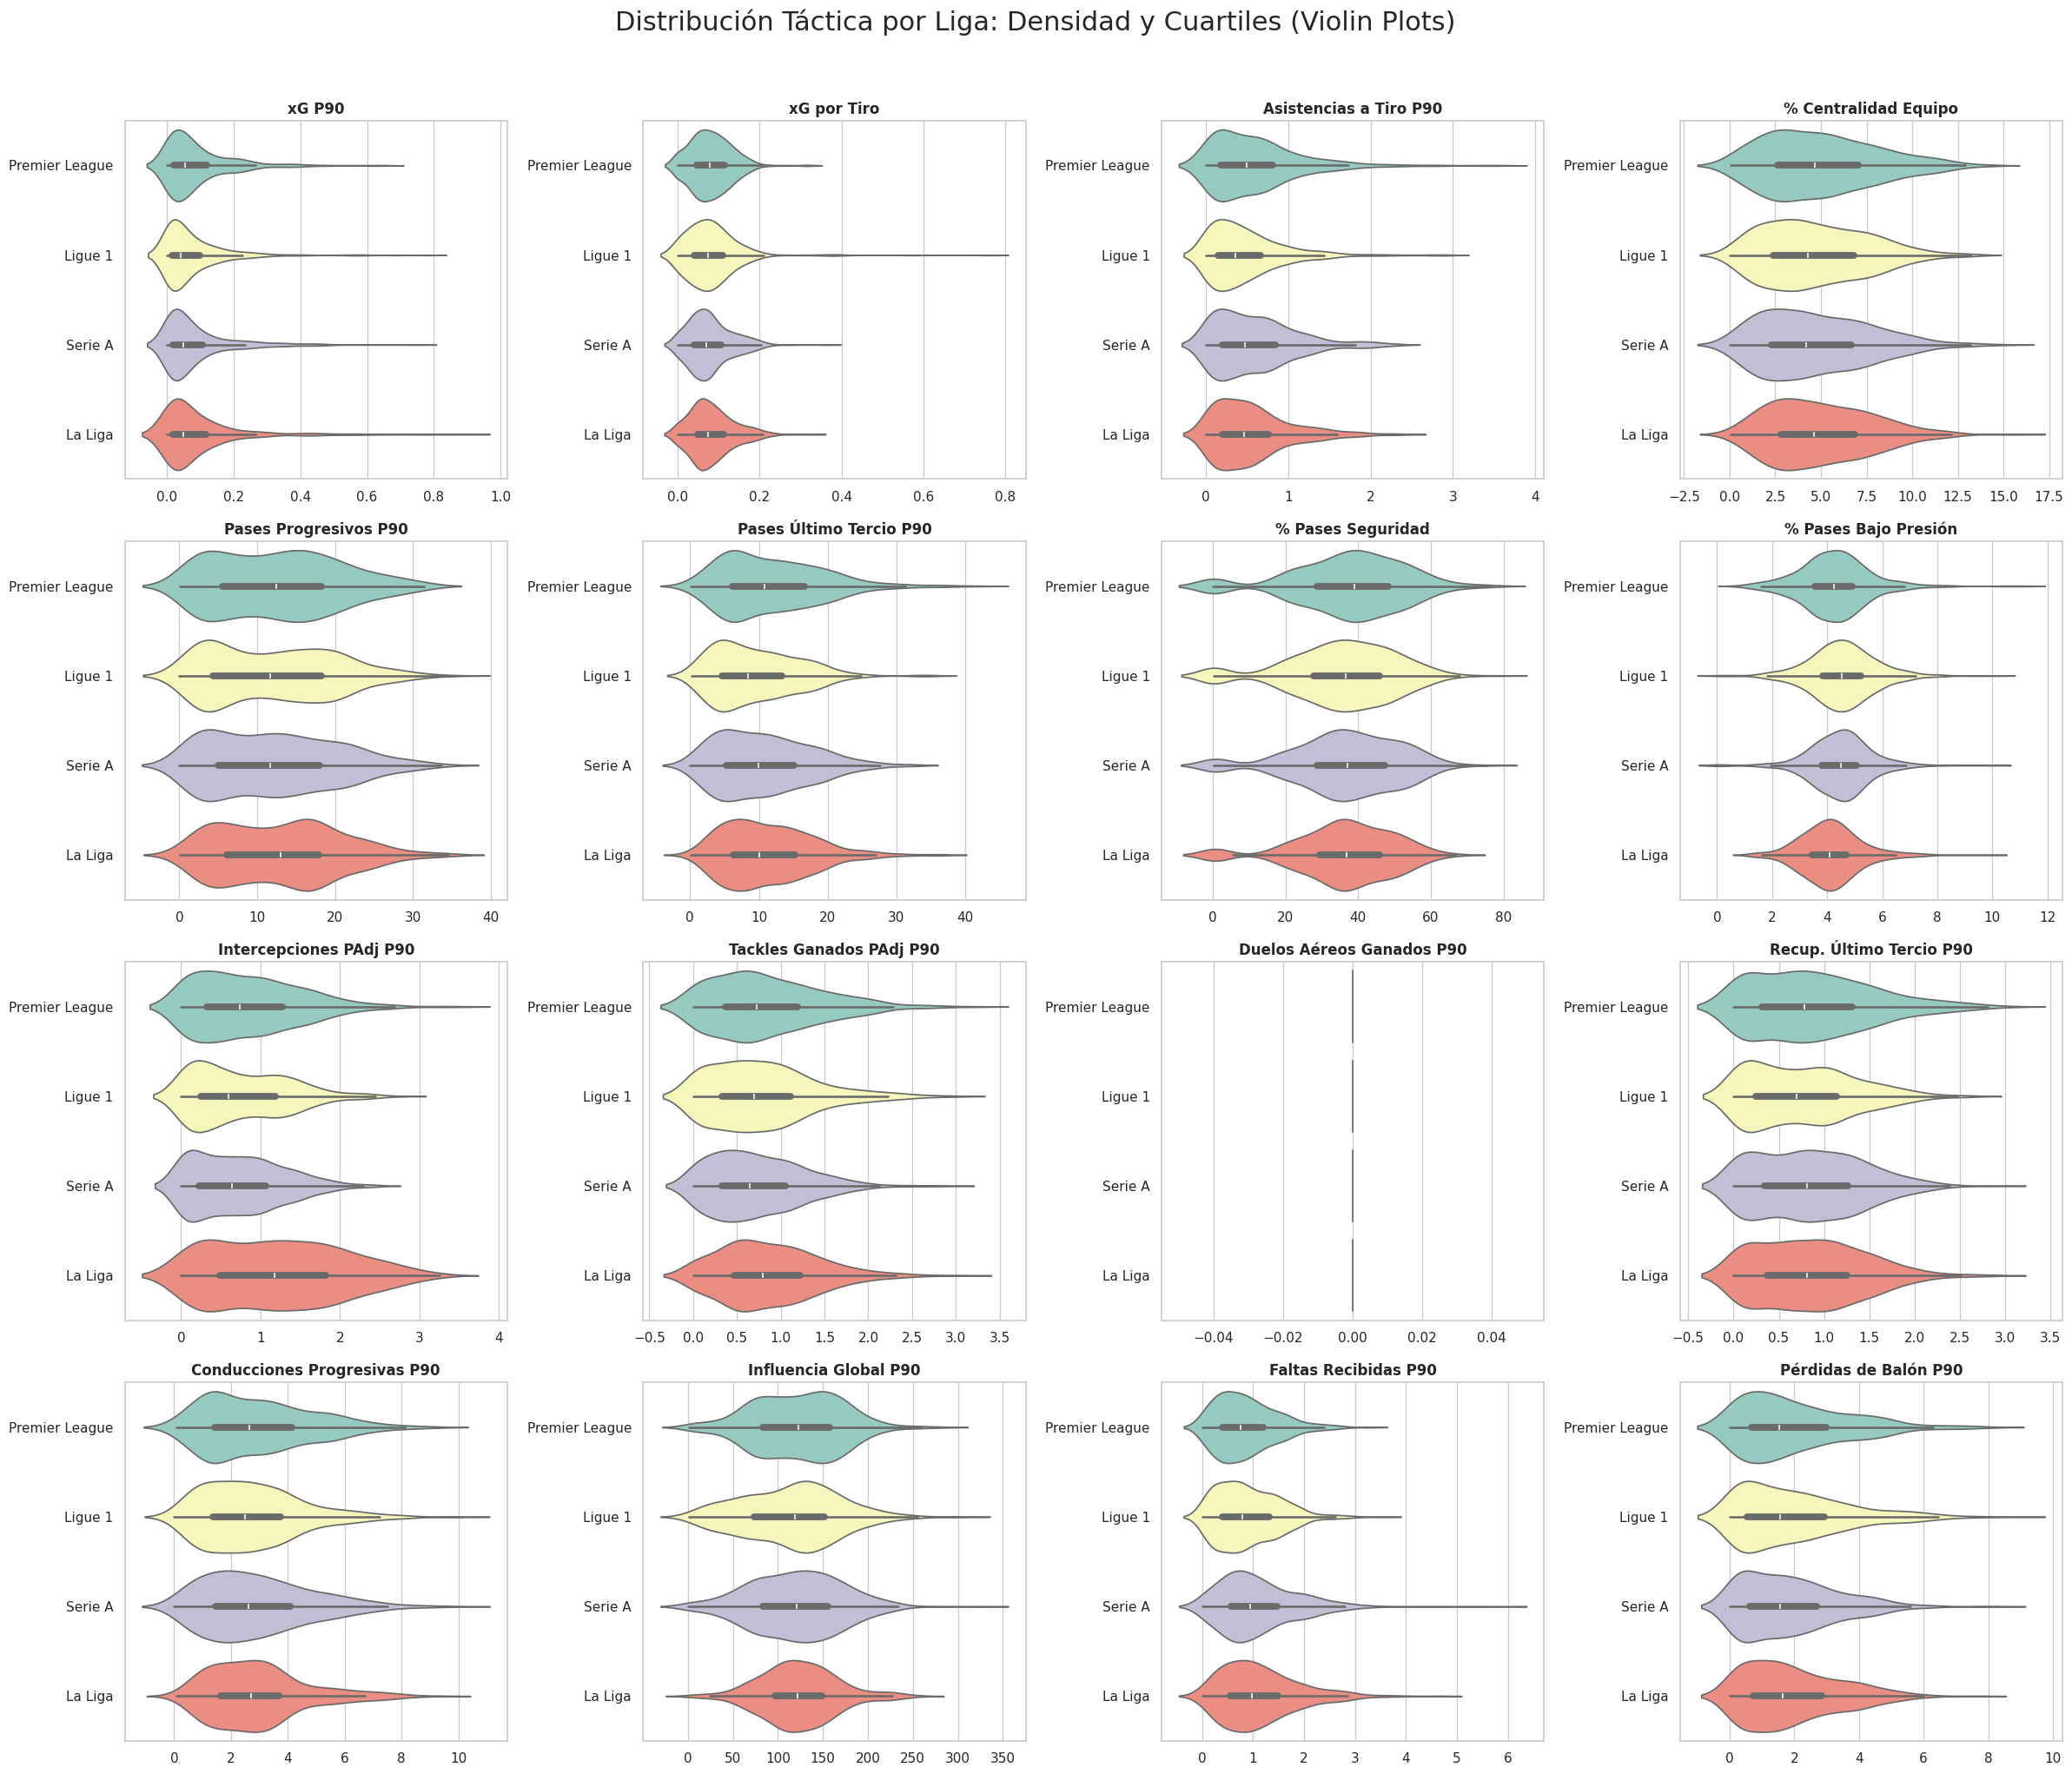

In [6]:

print("="*80)
print(" 🎻 COMPARACIÓN DE DISTRIBUCIONES Y DENSIDAD POR LIGA")
print("="*80)

# Configuración visual
sns.set_theme(style="whitegrid")

# Crear el lienzo 4x4
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
fig.suptitle('Distribución Táctica por Liga: Densidad y Cuartiles (Violin Plots)', fontsize=22, y=1.02)
axes = axes.flatten()

# Generar un Violin Plot para cada variable
for i, col in enumerate(columnas_modelo):
    # inner='box' dibuja el boxplot en miniatura dentro del violín
    sns.violinplot(data=df_modelo_final, x=col, y='competition_name', ax=axes[i], palette='Set3', inner='box')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()



### 🏆 Análisis de Atípicos Extremos: Radiografía Táctica de las Grandes Ligas (2015-2016)

El análisis de valores atípicos (*outliers*) nos permite ir más allá de la estadística descriptiva tradicional para identificar a los jugadores que rompieron moldes tácticos y estadísticos durante la temporada 2015-2016. A continuación, se detalla la interpretación de los comportamientos más sobresalientes por cada dimensión del juego:

*   **El Poderío Absoluto de Cara al Gol (`xG P90`):**
    Cristiano Ronaldo destaca con una diferencia monumental en los goles esperados por cada 90 minutos, registrando un impresionante `0.89`. Esto demuestra el poderío de un delantero que promedia prácticamente un gol cantado por partido. Lo llamativo a nivel narrativo es la ausencia de Lionel Messi en este top de finalización pura por volumen en este filtro específico, quedando el podio de La Liga acaparado por el Real Madrid con Ronaldo y Karim Benzema (0.75), acompañados de cerca por Luis Suárez (0.78).

*   **Anomalías en la Eficiencia de Remate (`xG por Tiro`):**
    Un caso de estudio atípico y sumamente curioso es el del defensa Romain Genevois (OGC Nice), quien registra un asombroso `0.76` en xG por tiro. Si bien este valor extremo suele explicarse como un sesgo matemático debido a un volumen muy bajo de remates totales (probablemente un par de remates a bocajarro en toda la temporada que inflaron su promedio), no deja de ser un dato pintoresco y atípico digno de mención en la línea defensiva.

*   **Los Directores de Orquesta en Creación:**
    Mesut Özil (Arsenal) demostró un rendimiento verdaderamente notable en la Premier League, consolidándose como el máximo referente de las 4 grandes ligas tanto en **Pases al Último Tercio (41.84)** como en **Asistencias a Tiro (3.57)**. Su capacidad para conectar el mediocampo con la zona de definición fue inigualable en ese periodo.

*   **El Sostén Táctico de los Equipos:**
    *   **Arsenal:** Alexis Sánchez aparece como el único jugador de la Premier League en superar las 3 recuperaciones de balón en el último tercio por partido (`3.04`). Si a esto le sumamos el dominio de Özil y la presencia de Santi Cazorla entre los líderes de **Influencia Global (281.23)**, se evidencia que el Arsenal de esa temporada basaba toda su competitividad y volumen de juego en este núcleo de jugadores.
    *   **Paris Saint-Germain:** En la manija del equipo parisino, los mediocampistas Thiago Motta (`303.92`) y Marco Verratti (`291.54`) dominaron con absoluta autoridad la **Influencia Global P90** de toda Europa, siendo el motor indiscutible del juego de posesión y salida del PSG.

*   **Imán de Faltas y Desequilibrio:**
    Como era de esperarse por su estilo de regate constante, Neymar Jr. lidera con holgura las **Faltas Recibidas (`4.64`)** en España. Sin embargo, el dato revelador lo aporta el fútbol italiano: Franco Damián Vázquez (Palermo) rompió los registros europeos recibiendo la impresionante cifra de `5.92` faltas por partido, superando a cualquier estrella mediática y demostrando que era el foco de todas las faltas defensivas de la Serie A.

In [7]:
import pandas as pd
from IPython.display import display

print("="*80)
print(" 🌟 IDENTIFICACIÓN DE ATÍPICOS EXTREMOS POR LIGA (TOP 3)")
print("="*80)

columnas_contexto = ['player', 'team', 'competition_name', 'position_group']

# Iteramos sobre cada variable para buscar a los atípicos
for col in columnas_modelo:
    print(f"\n" + "-"*60)
    print(f" ⚽ Métrica Analizada: {col}")
    print("-" * 60)

    # Agrupamos por liga y extraemos los 3 valores más altos
    top_por_liga = (
        df_modelo_final
        .groupby('competition_name', group_keys=False)
        .apply(lambda x: x.nlargest(3, col))
    )[columnas_contexto + [col]]

    # Ordenamos visualmente primero por liga y luego por la métrica de mayor a menor
    top_por_liga = top_por_liga.sort_values(by=['competition_name', col], ascending=[True, False])

    # Ocultamos el índice original para que la tabla sea más limpia
    display(top_por_liga.reset_index(drop=True))

 🌟 IDENTIFICACIÓN DE ATÍPICOS EXTREMOS POR LIGA (TOP 3)

------------------------------------------------------------
 ⚽ Métrica Analizada: xG P90
------------------------------------------------------------


/tmp/ipykernel_1289/2662057885.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, col))


,player,team,competition_name,position_group,xG P90
0,Cristiano Ronaldo dos Santos Aveiro,Real Madrid,La Liga,Delantero,0.893527
1,Luis Alberto Suárez Díaz,Barcelona,La Liga,Delantero,0.784978
2,Karim Benzema,Real Madrid,La Liga,Delantero,0.757823
3,Zlatan Ibrahimović,Paris Saint-Germain,Ligue 1,Delantero,0.780315
4,Vágner Silva de Souza,AS Monaco,Ligue 1,Delantero,0.685375
5,Alexandre Lacazette,Lyon,Ligue 1,Delantero,0.591372
6,Sergio Leonel Agüero del Castillo,Manchester City,Premier League,Delantero,0.648685
7,Jamie Vardy,Leicester City,Premier League,Delantero,0.624613
8,Harry Kane,Tottenham Hotspur,Premier League,Delantero,0.566045
9,Gonzalo Gerardo Higuaín,Napoli,Serie A,Delantero,0.747781



------------------------------------------------------------
 ⚽ Métrica Analizada: xG por Tiro
------------------------------------------------------------


/tmp/ipykernel_1289/2662057885.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, col))


...

/tmp/ipykernel_1289/2662057885.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, col))


,player,team,competition_name,position_group,Faltas Recibidas P90
0,Neymar da Silva Santos Junior,Barcelona,La Liga,Delantero,4.637071
1,Pedro Pablo Hernández,Celta Vigo,La Liga,Mediocampista,3.968610
2,Charly Musonda Junior,Real Betis,La Liga,Mediocampista,3.682699
3,Bryan Dabo,Montpellier,Ligue 1,Mediocampista,3.544222
4,Nicolas de Roussel de Préville,Stade de Reims,Ligue 1,Delantero,3.006812
5,Gilles Sunu,Angers,Ligue 1,Delantero,2.891269
6,Wilfried Zaha,Crystal Palace,Premier League,Delantero,3.276231
7,Alexis Alejandro Sánchez Sánchez,Arsenal,Premier League,Delantero,2.728319
8,Eden Hazard,Chelsea,Premier League,Delantero,2.695620
9,Franco Damián Vázquez,Palermo,Serie A,Mediocampista,5.918869


/tmp/ipykernel_1289/2662057885.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, col))



------------------------------------------------------------
 ⚽ Métrica Analizada: Pérdidas de Balón P90
------------------------------------------------------------


,player,team,competition_name,position_group,Pérdidas de Balón P90
0,Isaac Ajayi Success,Granada,La Liga,Delantero,7.668639
1,Fabián Ariel Orellana Valenzuela,Celta Vigo,La Liga,Delantero,6.232854
2,Neymar da Silva Santos Junior,Barcelona,La Liga,Delantero,6.007777
3,Sofiane Boufal,Lille,Ligue 1,Delantero,8.771499
4,Abdul Majeed Waris,Lorient,Ligue 1,Delantero,7.868571
5,Rodrigue Casimir Ninga,Montpellier,Ligue 1,Delantero,7.525729
6,Wilfried Zaha,Crystal Palace,Premier League,Delantero,8.094218
7,Anthony Martial,Manchester United,Premier League,Delantero,7.417262
8,Diego da Silva Costa,Chelsea,Premier League,Delantero,7.406212
9,Franco Damián Vázquez,Palermo,Serie A,Mediocampista,8.269822


## 4. Segmentación Táctica por Posición: La Prueba de Fuego

A diferencia de la comparación por ligas, donde buscábamos homogeneidad, al segmentar por `position_group` (Defensas, Delanteros, Mediocampistas y Porteros) **esperamos encontrar diferencias abismales**. Si el modelo matemático no logra diferenciar a un central de un extremo basado en estos promedios, el futuro algoritmo (PCA) fracasará.

Afortunadamente, el análisis descriptivo y de variabilidad confirma que nuestras 16 métricas capturan la esencia pura de los roles tácticos del fútbol:

### 🎯 1. Finalización y Creación (El monopolio del área)
*   **xG P90 y xG por Tiro:** Como dicta la lógica, los Delanteros dominan absolutamente estas métricas (0.183 xG P90 frente a los 0.032 de los defensas), exhibiendo también la mayor volatilidad (desviación estándar) en atacantes. Esto refleja que la ocasión de gol es un recurso altamente concentrado en pocos jugadores. Los porteros, naturalmente, registran valores nulos.
*   **Asistencias a Tiro:** Curiosamente, es una estadística mucho más democrática. Delanteros y Mediocampistas rondan valores muy similares (rondando 0.7), lo que demuestra que el último pase antes del tiro puede provenir de distintas posiciones.

### 🏗️ 2. Construcción y Progresión (Desde el fondo)
*   **Influencia y Centralidad:** La participación en el juego crece a medida que retrocedemos en el campo. Los Portero y Defensas superan ampliamente la centralidad de los jugadores de ataque. Las jugadas nacen desde atrás.
*   **Pases Progresivos:** Los reyes de la progresión son los Porteros (25.2) y Defensas (17.0). Al estar en la base de la jugada, la inmensa mayoría de sus pases van hacia adelante.

### 🛡️ 3. El Paradigma de la Presión y la Seguridad
*   **La paradoja del Pase de Seguridad:** Los Delanteros lideran esta métrica con un altísimo 50.2%, mientras que los Porteros apenas registran un 0.6%. Esto ocurre porque, a medida que el equipo avanza en el campo, los espacios se reducen y romper la última línea rival es sumamente difícil. El atacante suele verse obligado a tocar hacia atrás (pase de seguridad) para mantener la posesión.
*   **Conducciones Progresivas:** Rompiendo el mito de que los atacantes conducen más, los datos muestran que los Defensas avanzan más metros con el balón dominado que los Delanteros. El central tiene el espacio físico para salir jugando, mientras que el punta recibe sin espacio y bajo marca férrea.

### ⚔️ 4. Destrucción y Toma de Riesgos
*   **Pérdidas de Balón:** Los Delanteros (3.28) lideran cómodamente las pérdidas. Es el precio natural que asumen los roles creativos al intentar regates, filtrar pases clave o jugar en zonas de máxima densidad rival.
*   **Intercepciones y Tackles vs. Recuperaciones Altas:** La defensa tradicional (tackles/intercepciones) está dominada, como era de esperar, por la línea defensiva. Sin embargo, en la métrica *Recuperaciones en el Último Tercio*, los Delanteros toman el primer lugar, capturando el comportamiento de los equipos que ejercen bloque alto y presión tras pérdida.

In [8]:
import pandas as pd
from IPython.display import display

print("="*80)
print(" 🛡️ COMPARACIÓN TÁCTICA: PROMEDIOS MÉTRICOS POR POSICIÓN")
print("="*80)

# Calculamos la media de cada métrica agrupada por la posición del jugador
resumen_pos_media = df_modelo_final.groupby('position_group')[columnas_modelo].mean().T

# Ordenamos alfabéticamente las columnas para mantener la consistencia
resumen_pos_media = resumen_pos_media.sort_index(axis=1)

display(resumen_pos_media.round(3))

print("\n" + "="*80)
print(" 🔍 COMPARACIÓN DE VOLATILIDAD: DESVIACIÓN ESTÁNDAR POR POSICIÓN")
print("="*80)

# Calculamos la desviación estándar para ver en qué posición hay más desigualdad
resumen_pos_std = df_modelo_final.groupby('position_group')[columnas_modelo].std().T
resumen_pos_std = resumen_pos_std.sort_index(axis=1)

display(resumen_pos_std.round(3))

 🛡️ COMPARACIÓN TÁCTICA: PROMEDIOS MÉTRICOS POR POSICIÓN


position_group,Defensa,Delantero,Mediocampista,Portero
xG P90,0.032,0.183,0.068,0.000
xG por Tiro,0.077,0.116,0.071,0.003
Asistencias a Tiro P90,0.346,0.717,0.716,0.024
% Centralidad Equipo,5.824,3.023,5.314,4.877
Pases Progresivos P90,17.096,4.739,11.547,25.261
Pases Último Tercio P90,10.635,10.467,12.373,3.932
% Pases Seguridad,29.297,50.256,38.744,0.601
% Pases Bajo Presión,3.989,4.814,4.742,2.269
Intercepciones PAdj P90,1.384,0.386,0.912,0.003
Tackles Ganados PAdj P90,0.987,0.464,1.040,0.001



 🔍 COMPARACIÓN DE VOLATILIDAD: DESVIACIÓN ESTÁNDAR POR POSICIÓN


position_group,Defensa,Delantero,Mediocampista,Portero
xG P90,0.027,0.145,0.059,0.001
xG por Tiro,0.059,0.056,0.041,0.023
Asistencias a Tiro P90,0.316,0.519,0.510,0.032
% Centralidad Equipo,2.644,2.087,3.153,1.988
Pases Progresivos P90,5.530,3.478,6.332,5.172
Pases Último Tercio P90,6.509,6.632,6.573,2.198
% Pases Seguridad,8.874,8.212,7.378,0.752
% Pases Bajo Presión,0.790,1.298,0.971,0.901
Intercepciones PAdj P90,0.623,0.346,0.578,0.012
Tackles Ganados PAdj P90,0.471,0.331,0.619,0.006


 🎻 COMPARACIÓN DE DISTRIBUCIONES Y DENSIDAD POR POSICIÓN


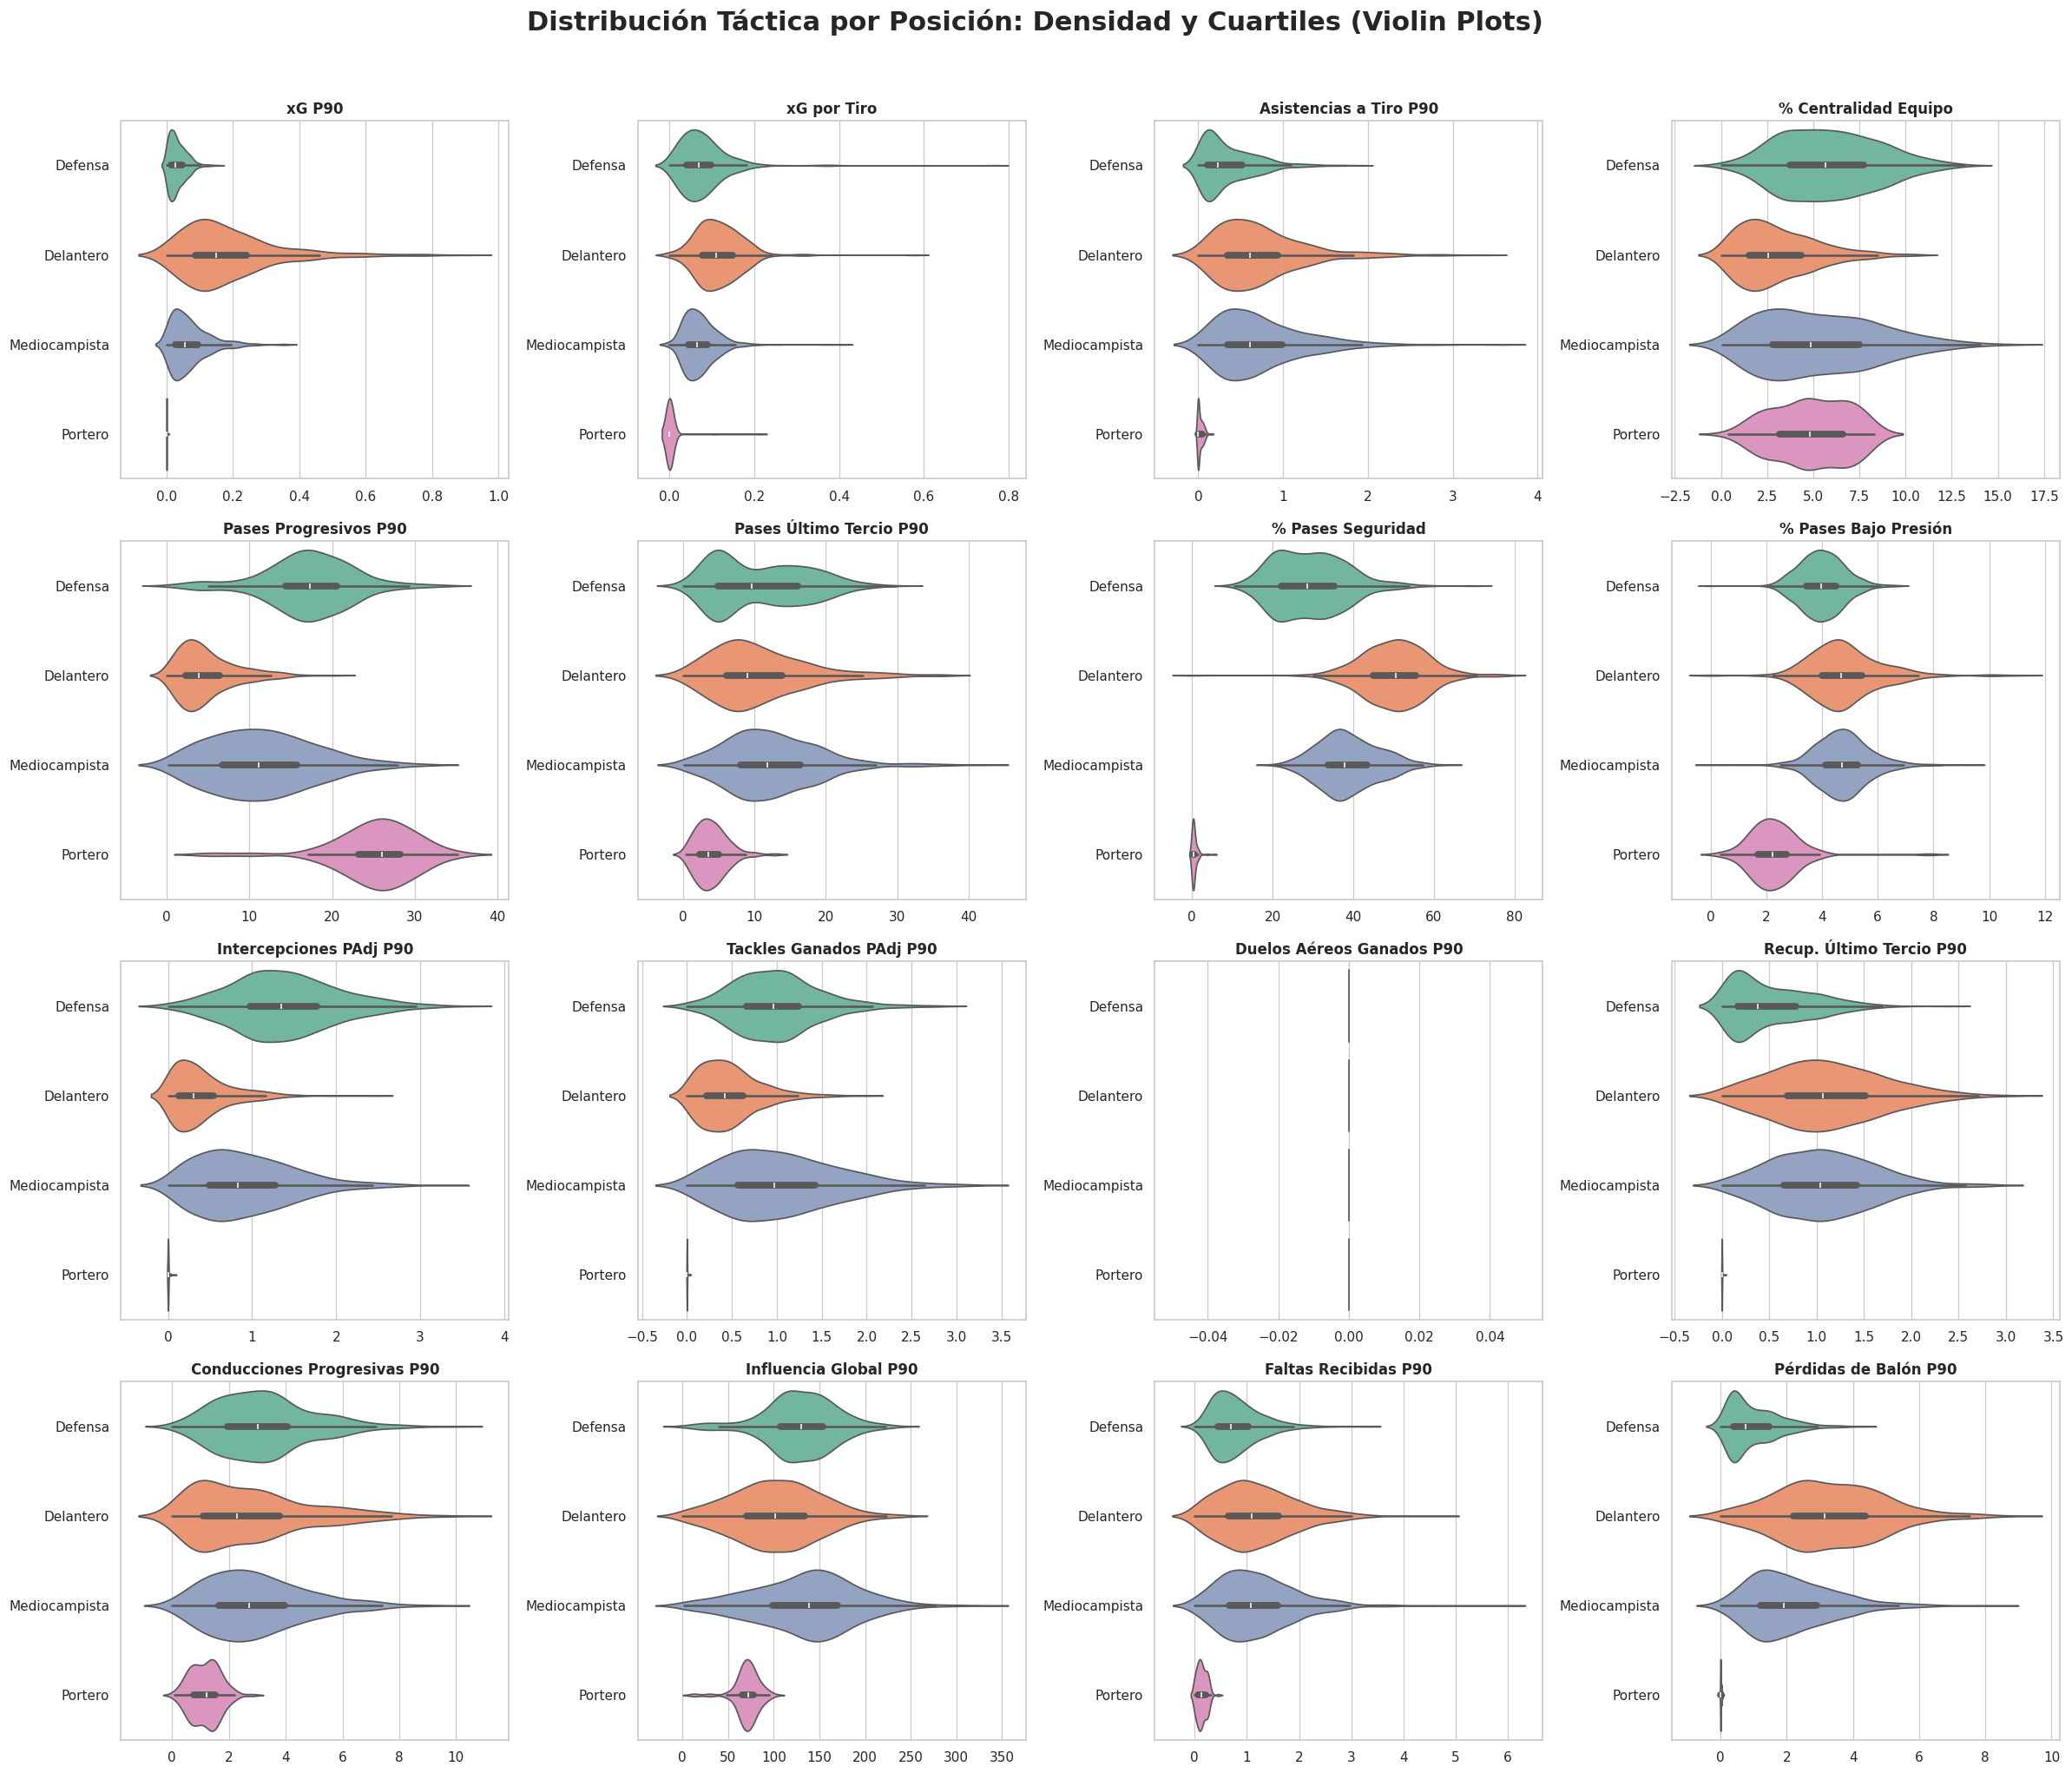

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print(" 🎻 COMPARACIÓN DE DISTRIBUCIONES Y DENSIDAD POR POSICIÓN")
print("="*80)

# Configuración visual
sns.set_theme(style="whitegrid")

# Crear el lienzo 4x4
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
fig.suptitle('Distribución Táctica por Posición: Densidad y Cuartiles (Violin Plots)', fontsize=22, y=1.02, fontweight='bold')
axes = axes.flatten()

# Generar un Violin Plot para cada variable
for i, col in enumerate(columnas_modelo):
    sns.violinplot(
        data=df_modelo_final,
        x=col,
        y='position_group',
        hue='position_group',
        ax=axes[i],
        palette='Set2',
        inner='box',
        legend=False
    )
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()